In [8]:
# Install once
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn imbalanced-learn shap joblib

import warnings
warnings.filterwarnings("ignore")

import os
import json
import random
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

import shap

print("TensorFlow Version :", tf.__version__)
print("Libraries Imported Successfully")

TensorFlow Version : 2.21.0
Libraries Imported Successfully



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
df = pd.read_csv(r"C:\Users\ADMIN\Downloads\healthcare_fraud_detection.csv")

In [11]:
df = pd.read_csv(r"C:\Users\ADMIN\Downloads\healthcare_fraud_detection.csv")

print("Dataset Loaded Successfully")
print(df.shape)

df.head()

Dataset Loaded Successfully
(10000, 20)


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [12]:
# ==========================================
# Dataset Overview
# ==========================================

print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("FIRST 5 RECORDS")
print("="*60)
display(df.head())

print("\n")

print("="*60)
print("LAST 5 RECORDS")
print("="*60)
display(df.tail())

print("\n")

print("="*60)
print("COLUMN NAMES")
print("="*60)
print(df.columns.tolist())

DATASET SHAPE
(10000, 20)


FIRST 5 RECORDS


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0




LAST 5 RECORDS


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
9995,P0289,C0009995,79,Male,E78.5,71046,590.19,205.00,Private,2024-09-24,2,115,Internal Medicine,PA,Approved,1,2,Inpatient,1,3.0
9996,P0248,C0009996,66,Male,K21.9,93000,219.73,191.89,Self-Pay,2023-01-04,6,73,Orthopedics,IL,Approved,0,5,Inpatient,0,6.0
9997,P0122,C0009997,43,Female,F41.9,99213,505.24,447.94,Medicare,2024-06-30,6,59,Neurology,OH,Rejected,0,5,Emergency,1,0.0
9998,P0072,C0009998,39,Female,I10,93000,564.25,507.18,Medicare,2022-03-15,8,55,Cardiology,TX,Pending,0,5,Emergency,0,6.0
9999,P0137,C0009999,26,Male,J18.9,71046,564.52,563.74,Medicaid,2023-01-24,2,86,Neurology,CA,Approved,0,3,Outpatient,0,NaN




COLUMN NAMES
['Provider_ID', 'Claim_ID', 'Patient_Age', 'Patient_Gender', 'Diagnosis_Code', 'Procedure_Code', 'Claim_Amount', 'Approved_Amount', 'Insurance_Type', 'Claim_Submission_Date', 'Days_Between_Service_and_Claim', 'Number_of_Claims_Per_Provider_Monthly', 'Provider_Specialty', 'Patient_State', 'Claim_Status', 'Is_Fraud', 'Length_of_Stay', 'Visit_Type', 'Chronic_Condition_Flag', 'Prior_Visits_12m']


In [13]:
# ==========================================
# Dataset Information
# ==========================================

print("="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()

print("\n")

print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)

display(df.describe())

print("\n")

print("="*60)
print("STATISTICAL SUMMARY (INCLUDING CATEGORICAL)")
print("="*60)

display(df.describe(include="all"))

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  object 
 1   Claim_ID                               10000 non-null  object 
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  object 
 4   Diagnosis_Code                         10000 non-null  object 
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   object 
 9   Claim_Submission_Date                  10000 non-null  object 
 10  Days_Between_Service_and_Claim         10000 non-nu

,Patient_Age,Procedure_Code,Claim_Amount,Approved_Amount,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Is_Fraud,Length_of_Stay,Chronic_Condition_Flag,Prior_Visits_12m
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,9650.000000
mean,49.755000,86905.21170,572.804406,475.514157,14.413800,68.628000,0.082900,2.19930,0.292000,3.026425
std,17.910144,14965.32496,406.202437,323.257165,8.489875,14.905872,0.275745,1.71046,0.454705,1.722789
min,1.000000,36415.00000,60.210000,50.350000,0.000000,42.000000,0.000000,0.00000,0.000000,0.000000
25%,37.750000,80053.00000,305.205000,257.200000,7.000000,60.000000,0.000000,1.00000,0.000000,2.000000
50%,50.000000,93000.00000,461.225000,388.370000,14.000000,66.000000,0.000000,2.00000,0.000000,3.000000
75%,62.000000,99213.00000,711.365000,598.347500,22.000000,72.000000,0.000000,3.00000,1.000000,4.000000
max,95.000000,99214.00000,6590.700000,4270.890000,29.000000,144.000000,1.000000,5.00000,1.000000,12.000000




STATISTICAL SUMMARY (INCLUDING CATEGORICAL)


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
count,10000,10000,10000.000000,10000,10000,10000.00000,10000.000000,10000.000000,9650,10000,10000.000000,10000.000000,9650,10000,10000,10000.000000,10000.00000,10000,10000.000000,9650.000000
unique,300,10000,NaN,2,10,NaN,NaN,NaN,4,1476,NaN,NaN,6,8,3,NaN,NaN,3,NaN,NaN
top,P0142,C0000000,NaN,Female,M54.5,NaN,NaN,NaN,Medicare,2023-09-11,NaN,NaN,Internal Medicine,PA,Approved,NaN,NaN,Outpatient,NaN,NaN
freq,52,1,NaN,5001,1055,NaN,NaN,NaN,2425,21,NaN,NaN,2019,1327,7053,NaN,NaN,3423,NaN,NaN
mean,NaN,NaN,49.755000,NaN,NaN,86905.21170,572.804406,475.514157,NaN,NaN,14.413800,68.628000,NaN,NaN,NaN,0.082900,2.19930,NaN,0.292000,3.026425
std,NaN,NaN,17.910144,NaN,NaN,14965.32496,406.202437,323.257165,NaN,NaN,8.489875,14.905872,NaN,NaN,NaN,0.275745,1.71046,NaN,0.454705,1.722789
min,NaN,NaN,1.000000,NaN,NaN,36415.00000,60.210000,50.350000,NaN,NaN,0.000000,42.000000,NaN,NaN,NaN,0.000000,0.00000,NaN,0.000000,0.000000
25%,NaN,NaN,37.750000,NaN,NaN,80053.00000,305.205000,257.200000,NaN,NaN,7.000000,60.000000,NaN,NaN,NaN,0.000000,1.00000,NaN,0.000000,2.000000
50%,NaN,NaN,50.000000,NaN,NaN,93000.00000,461.225000,388.370000,NaN,NaN,14.000000,66.000000,NaN,NaN,NaN,0.000000,2.00000,NaN,0.000000,3.000000
75%,NaN,NaN,62.000000,NaN,NaN,99213.00000,711.365000,598.347500,NaN,NaN,22.000000,72.000000,NaN,NaN,NaN,0.000000,3.00000,NaN,1.000000,4.000000


In [14]:
# ==========================================
# Missing Values & Duplicates
# ==========================================

print("="*60)
print("MISSING VALUES")
print("="*60)

missing = df.isnull().sum()

display(missing[missing > 0])

print("\n")

print("="*60)
print("TOTAL DUPLICATE ROWS")
print("="*60)

print(df.duplicated().sum())

MISSING VALUES


Insurance_Type        350
Provider_Specialty    350
Prior_Visits_12m      350
dtype: int64



TOTAL DUPLICATE ROWS
0


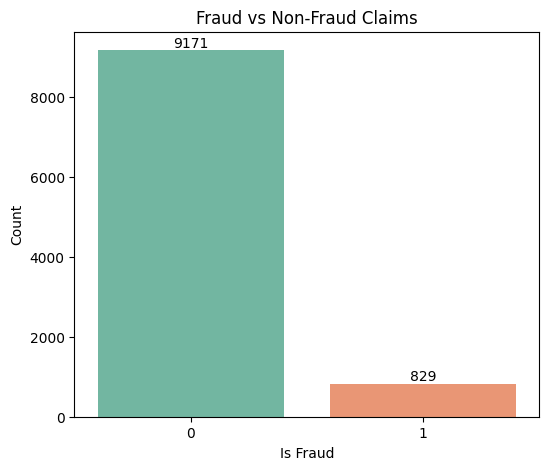

Is_Fraud
0    9171
1     829
Name: count, dtype: int64

Percentage Distribution

Is_Fraud
0    91.71
1     8.29
Name: proportion, dtype: float64


In [15]:
# ==========================================
# Fraud Distribution
# ==========================================

plt.figure(figsize=(6,5))

ax = sns.countplot(
    x="Is_Fraud",
    data=df,
    palette="Set2"
)

plt.title("Fraud vs Non-Fraud Claims")
plt.xlabel("Is Fraud")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

print(df["Is_Fraud"].value_counts())

print("\nPercentage Distribution\n")

print(df["Is_Fraud"].value_counts(normalize=True)*100)

Numerical Columns
Index(['Patient_Age', 'Procedure_Code', 'Claim_Amount', 'Approved_Amount',
       'Days_Between_Service_and_Claim',
       'Number_of_Claims_Per_Provider_Monthly', 'Is_Fraud', 'Length_of_Stay',
       'Chronic_Condition_Flag', 'Prior_Visits_12m'],
      dtype='object')


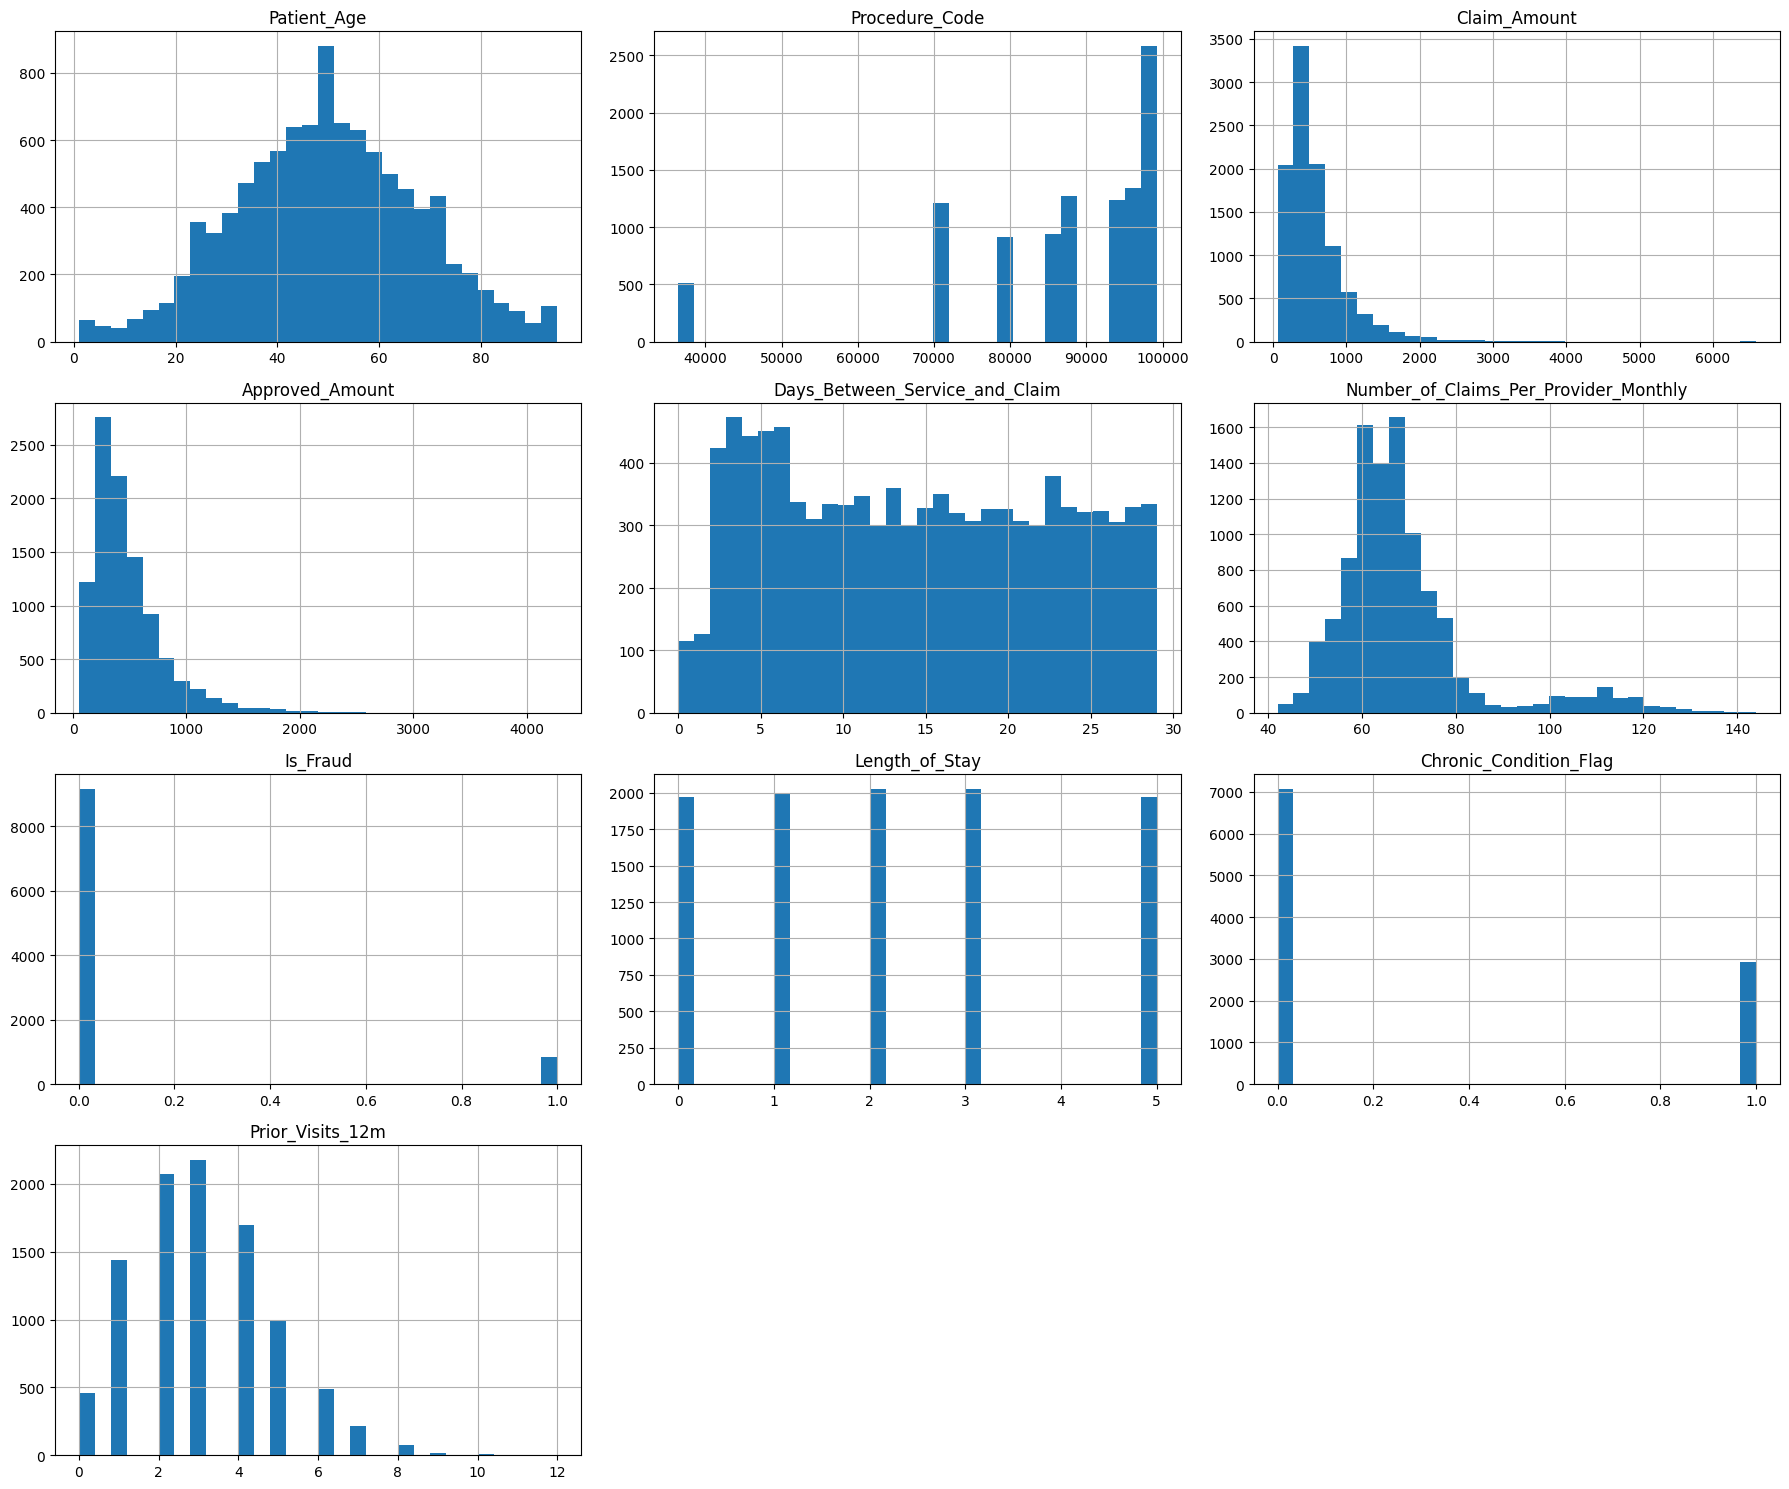

In [16]:
# ==========================================
# Numerical Features
# ==========================================

numerical_columns = df.select_dtypes(include=["int64","float64"]).columns

print("Numerical Columns")

print(numerical_columns)

df[numerical_columns].hist(
    figsize=(18,15),
    bins=30
)

plt.tight_layout()

plt.show()

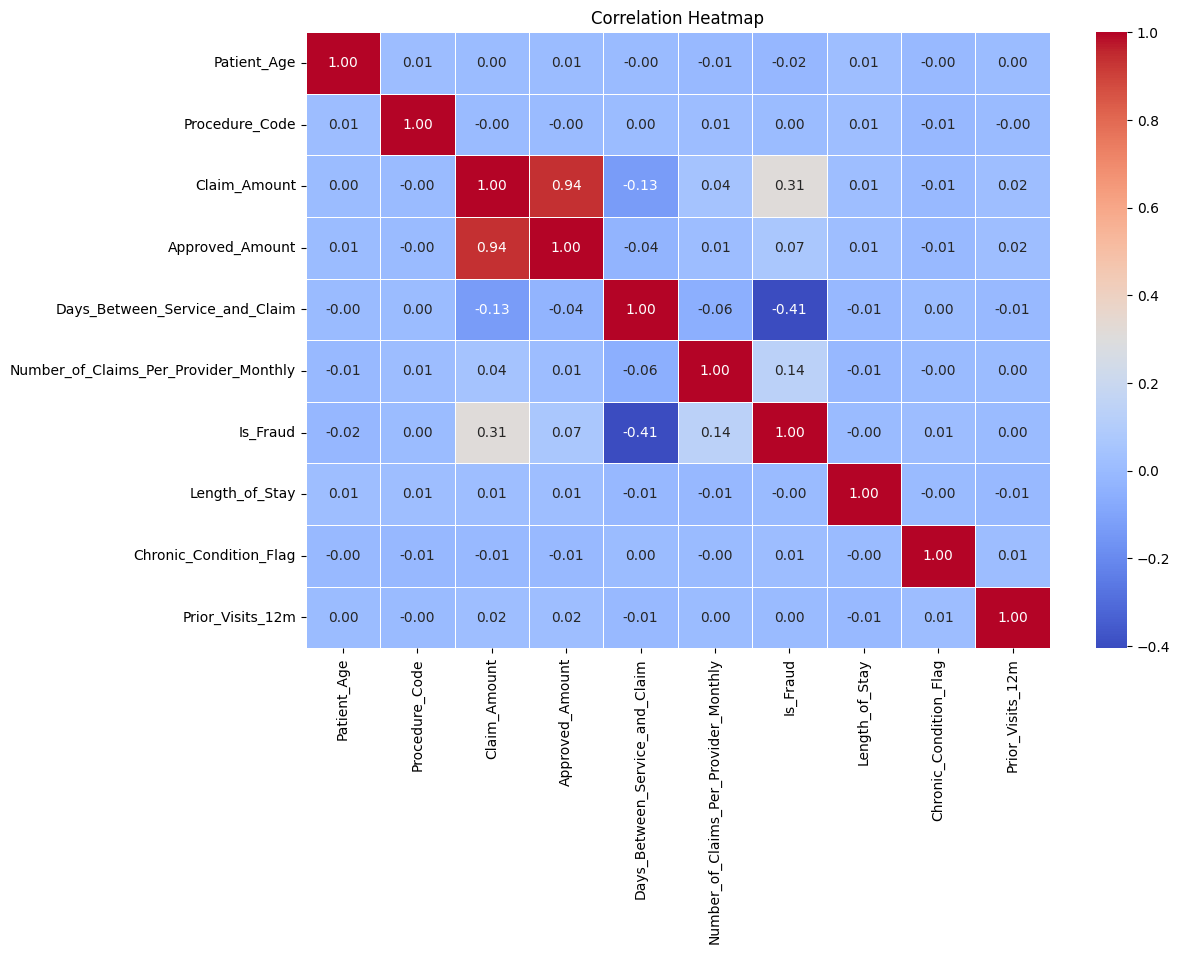

In [17]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

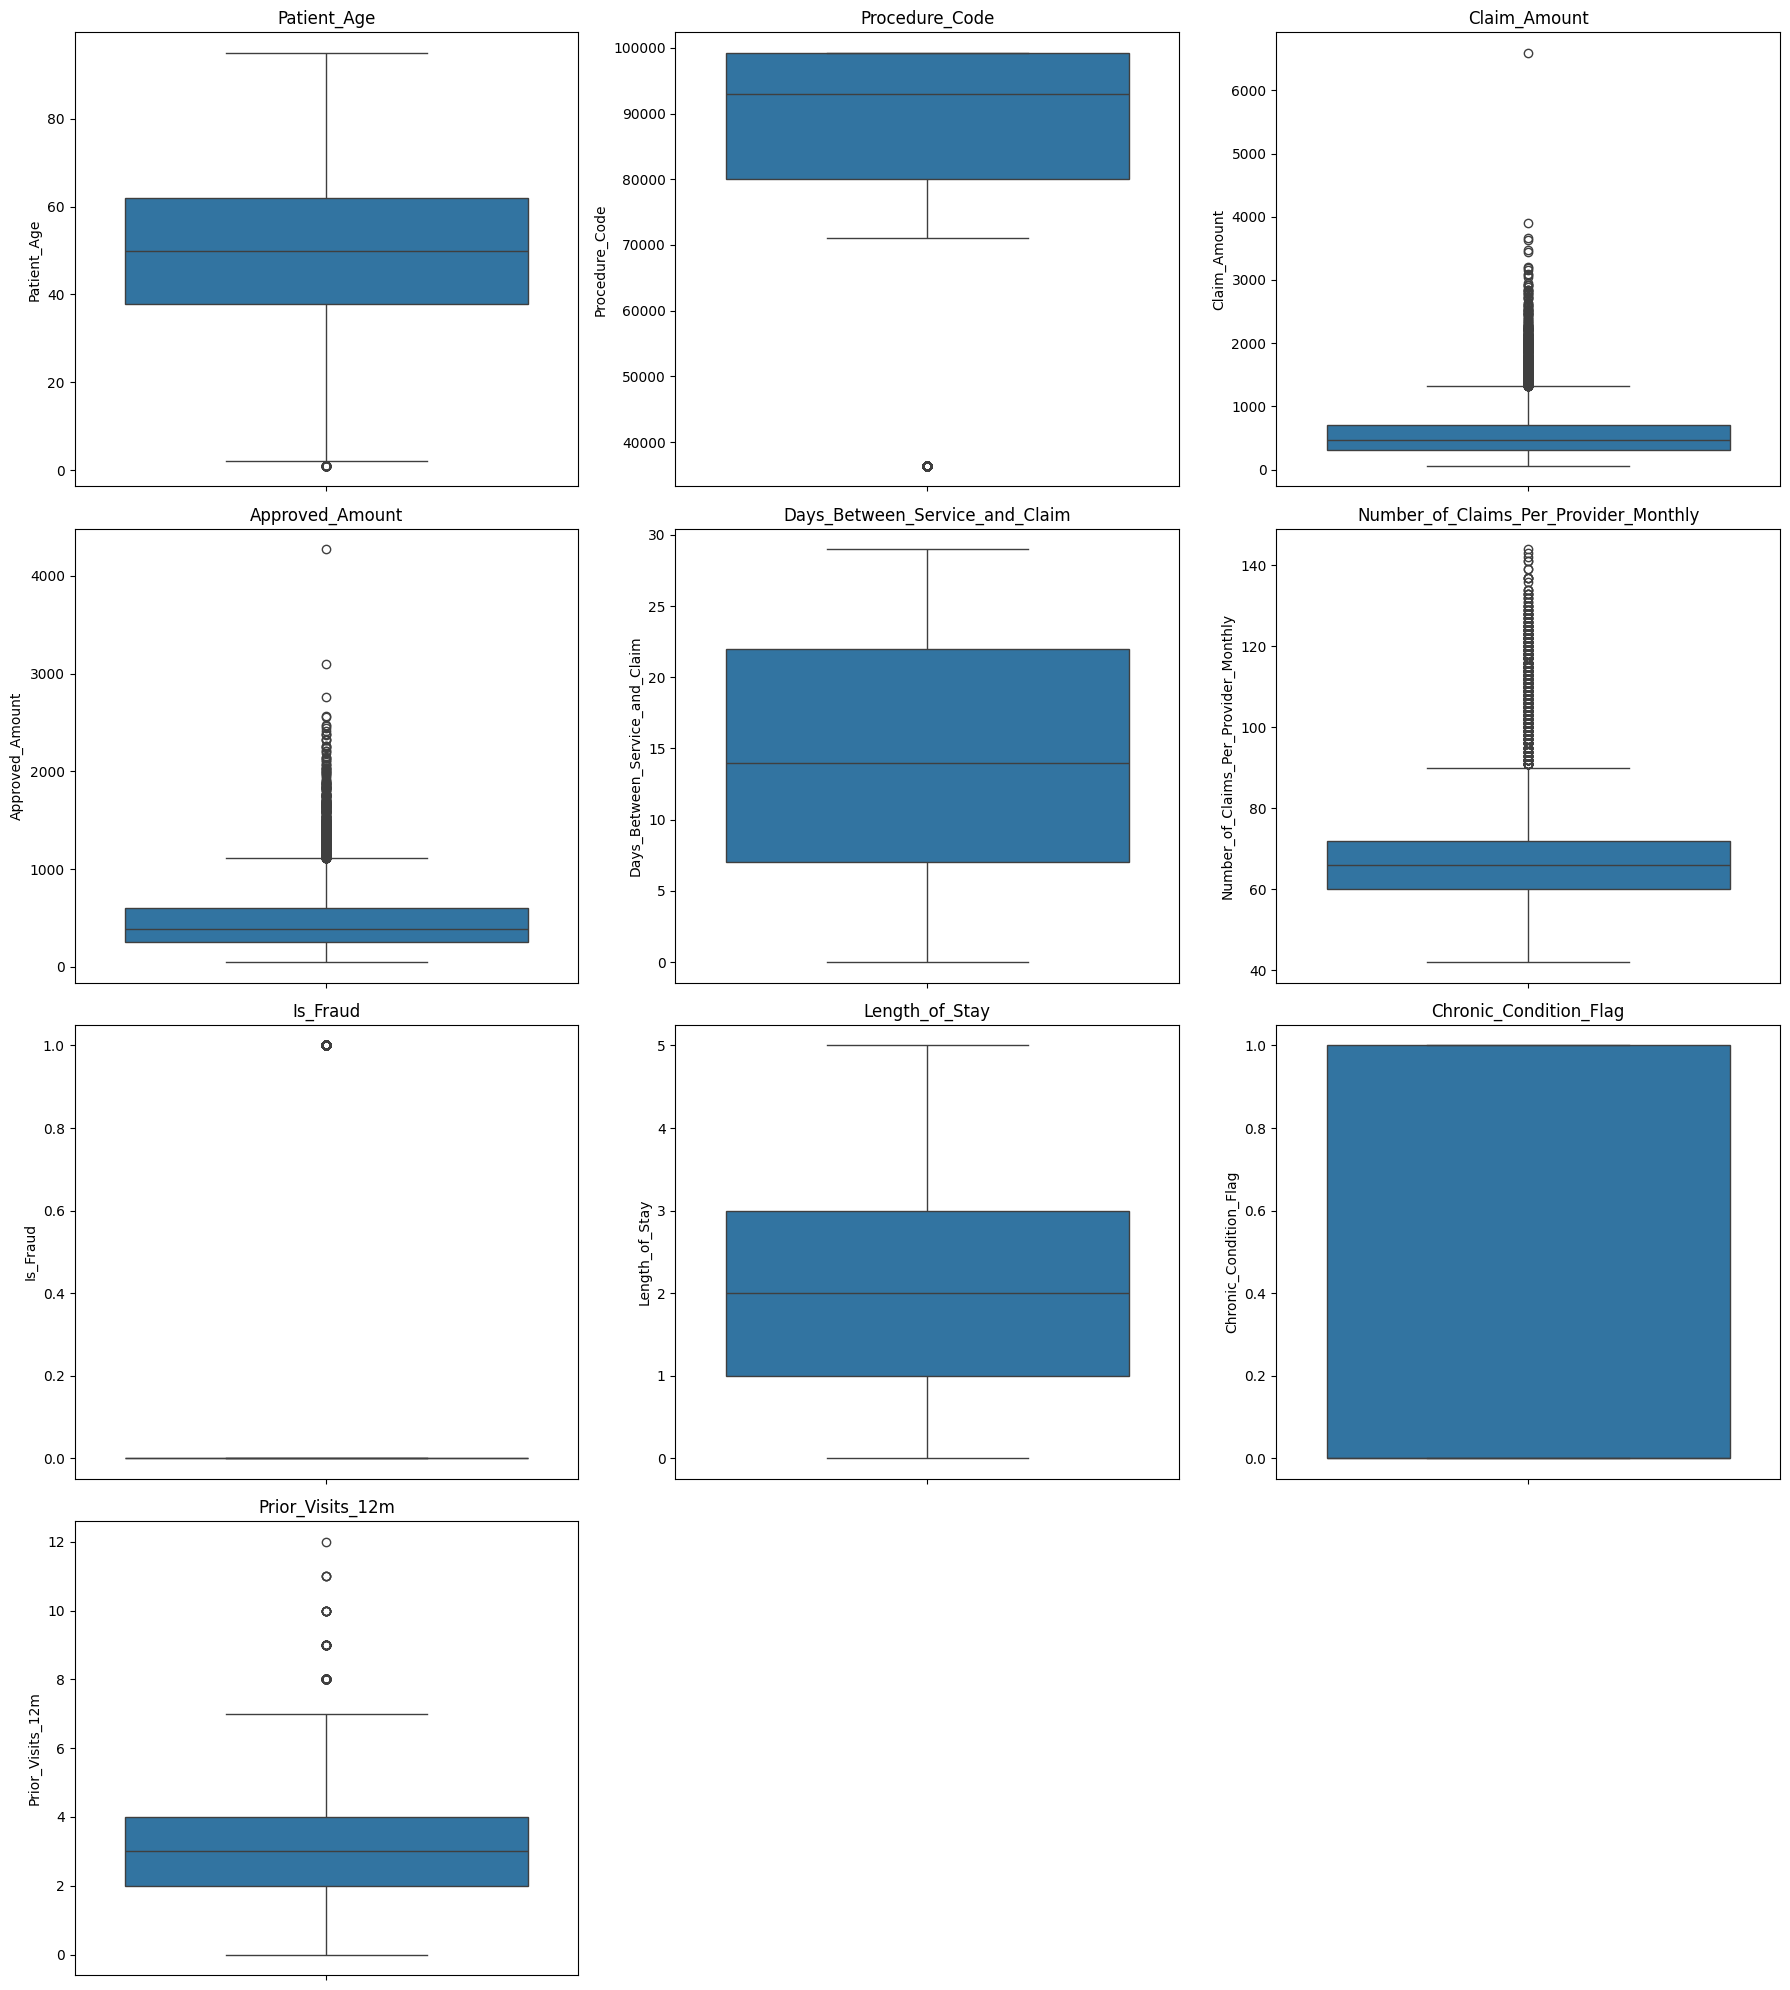

In [18]:
# ==========================================
# Outlier Detection
# ==========================================

numerical_columns = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(18,20))

for i, col in enumerate(numerical_columns):

    plt.subplot(4,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

Categorical Columns
Index(['Provider_ID', 'Claim_ID', 'Patient_Gender', 'Diagnosis_Code',
       'Insurance_Type', 'Claim_Submission_Date', 'Provider_Specialty',
       'Patient_State', 'Claim_Status', 'Visit_Type'],
      dtype='object')


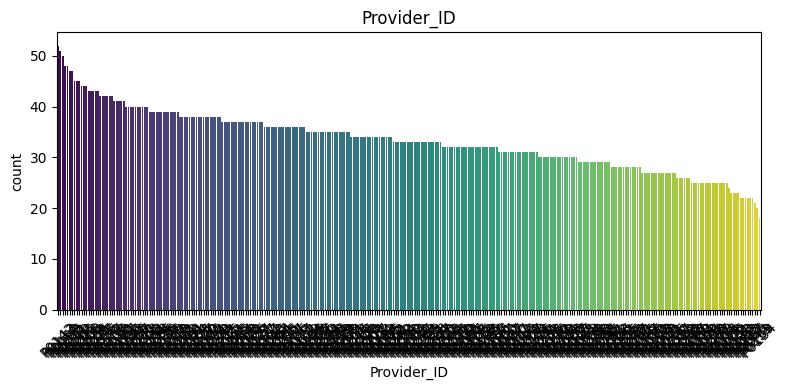

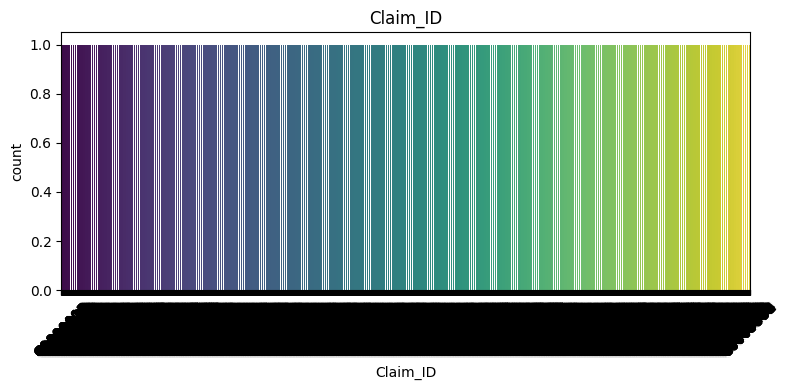

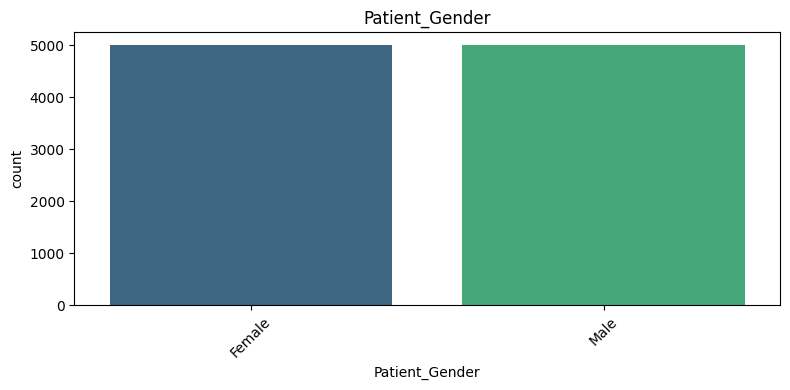

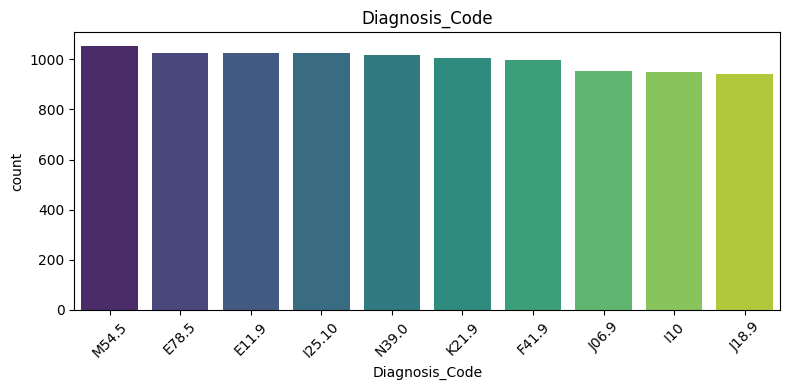

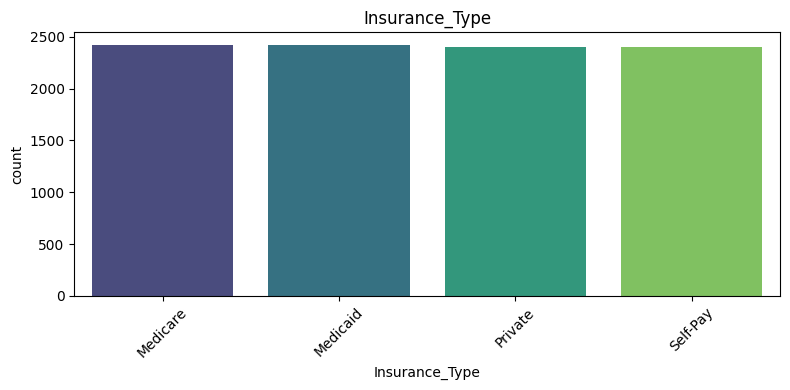

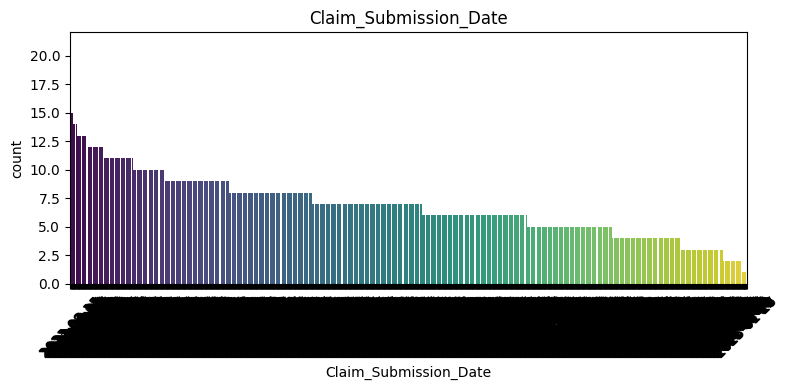

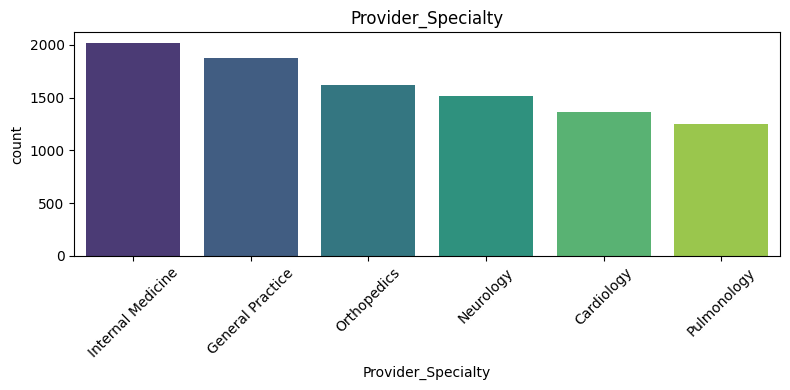

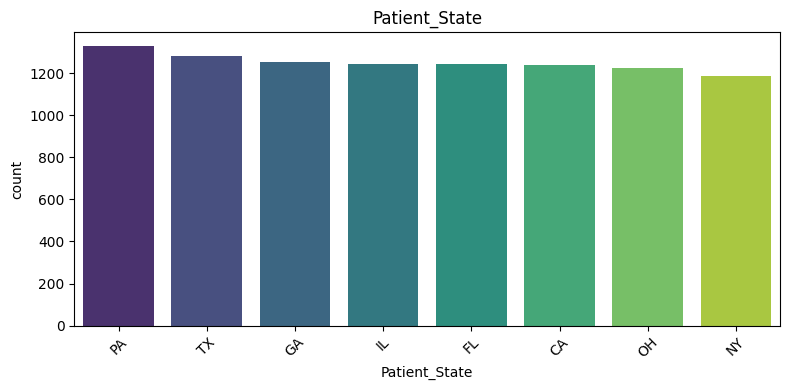

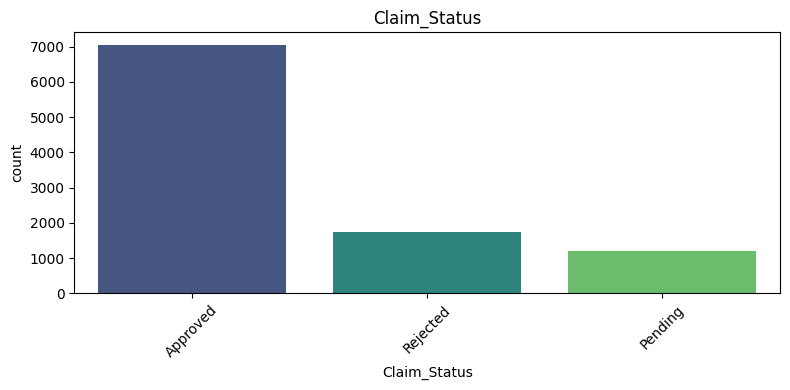

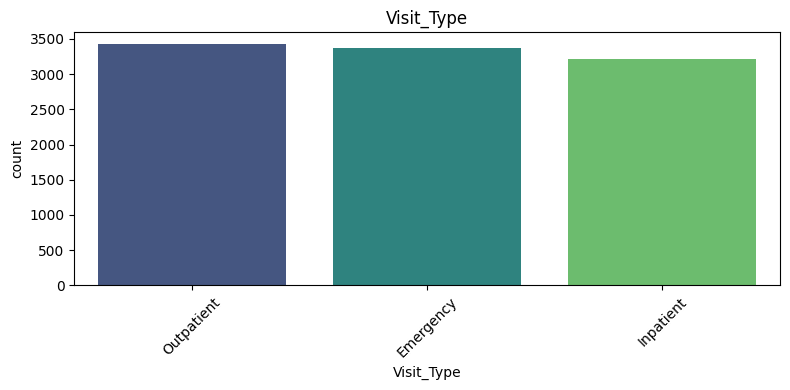

In [19]:
# ==========================================
# Categorical Features
# ==========================================

categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns")

print(categorical_columns)

for col in categorical_columns:

    plt.figure(figsize=(8,4))

    sns.countplot(
        x=df[col],
        order=df[col].value_counts().index,
        palette='viridis'
    )

    plt.title(col)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

In [39]:
# ==========================================================
# Remove ID columns (avoid data leakage)
# ==========================================================

drop_columns = [
    "Claim_ID",
    "Provider_ID",
    "Claim_Submission_Date"
]

df = df.drop(columns=drop_columns)

print("Dropped Columns:")
print(drop_columns)

Dropped Columns:
['Claim_ID', 'Provider_ID', 'Claim_Submission_Date']


In [40]:
# ==========================================
# Feature Engineering
# ==========================================

# Approval Ratio
df["Approval_Ratio"] = df["Approved_Amount"] / (df["Claim_Amount"] + 1)

# High Claim Flag
claim_threshold = df["Claim_Amount"].quantile(0.90)

df["High_Claim"] = (df["Claim_Amount"] > claim_threshold).astype(int)

# Long Stay Flag
df["Long_Stay"] = (df["Length_of_Stay"] >= 4).astype(int)

# Frequent Visitor
df["Frequent_Visitor"] = (df["Prior_Visits_12m"] >= 5).astype(int)

# High Provider Load
provider_threshold = df["Number_of_Claims_Per_Provider_Monthly"].quantile(0.90)

df["High_Provider_Load"] = (
    df["Number_of_Claims_Per_Provider_Monthly"] > provider_threshold
).astype(int)

# Risk Score
df["Risk_Score"] = (
    df["High_Claim"] +
    df["Long_Stay"] +
    df["Frequent_Visitor"] +
    df["High_Provider_Load"]
)

print("Feature Engineering Completed Successfully!")

print(df.head())

Feature Engineering Completed Successfully!
   Patient_Age Patient_Gender Diagnosis_Code  Procedure_Code  Claim_Amount  \
0           37           Male         I25.10           36415        443.51   
1           21         Female          E11.9           99213        467.50   
2           78         Female          J06.9           93000        591.69   
3           65           Male            I10           93000        235.15   
4           36           Male          M54.5           85025        487.96   

   Approved_Amount Insurance_Type  Days_Between_Service_and_Claim  \
0           393.16       Medicaid                              13   
1           461.33       Self-Pay                               5   
2           530.06       Medicaid                              29   
3           189.11        Private                              22   
4           369.91        Private                              21   

   Number_of_Claims_Per_Provider_Monthly Provider_Specialty  ...  \
0   

In [41]:
# ==========================================================
# Define Features and Target
# ==========================================================

TARGET = "Is_Fraud"

# Features
X = df.drop(columns=[TARGET])

# Target
y = df[TARGET]

print("="*60)
print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)
print("="*60)

Feature Matrix Shape : (10000, 22)
Target Shape         : (10000,)


In [42]:
# ==========================================================
# Identify Numerical & Categorical Columns
# ==========================================================

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features")
print(numerical_features)

print("\nCategorical Features")
print(categorical_features)

Numerical Features
['Patient_Age', 'Procedure_Code', 'Claim_Amount', 'Approved_Amount', 'Days_Between_Service_and_Claim', 'Number_of_Claims_Per_Provider_Monthly', 'Length_of_Stay', 'Chronic_Condition_Flag', 'Prior_Visits_12m', 'Approval_Ratio', 'High_Claim', 'Long_Stay', 'Frequent_Visitor', 'High_Provider_Load', 'Risk_Score']

Categorical Features
['Patient_Gender', 'Diagnosis_Code', 'Insurance_Type', 'Provider_Specialty', 'Patient_State', 'Claim_Status', 'Visit_Type']


In [43]:
# ==========================================================
# Preprocessing Pipeline
# ==========================================================

# Numerical pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing Pipeline Created Successfully!")

Preprocessing Pipeline Created Successfully!


In [44]:
# ==========================================================
# Train/Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("="*60)
print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)
print("="*60)

Training Set : (8000, 22)
Testing Set  : (2000, 22)


In [45]:
# ==========================================================
# Apply Preprocessing
# ==========================================================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training Shape :", X_train_processed.shape)
print("Testing Shape  :", X_test_processed.shape)

Training Shape : (8000, 51)
Testing Shape  : (2000, 51)


In [46]:
# ==========================================================
# Apply SMOTE
# ==========================================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("="*60)
print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

print("="*60)

Before SMOTE
Is_Fraud
0    7337
1     663
Name: count, dtype: int64

After SMOTE
Is_Fraud
0    7337
1    7337
Name: count, dtype: int64


In [47]:
# ==========================================================
# Build Deep Learning Model (TensorFlow + Keras)
# ==========================================================

input_dim = X_train_smote.shape[1]

model = Sequential([

    Dense(256, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.30),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.25),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.20),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')

])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │        13,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 57,473 (224.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [48]:
# ==========================================================
# Compile Model
# ==========================================================

model.compile(

    optimizer=Adam(learning_rate=0.001),

    loss='binary_crossentropy',

    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]

)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [49]:
# ==========================================================
# Training Callbacks
# ==========================================================

early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=10,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=5,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "model/best_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

print("Callbacks Ready!")

Callbacks Ready!


In [50]:
# ==========================================================
# Train Deep Learning Model
# ==========================================================

history = model.fit(

    X_train_smote,

    y_train_smote,

    validation_split=0.2,

    epochs=100,

    batch_size=64,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ],

    verbose=1

)

Epoch 1/100
181/184 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9562 - loss: 0.1220 - precision: 0.9402 - recall: 0.9434
Epoch 1: val_accuracy improved from None to 0.99932, saving model to model/best_model.keras

Epoch 1: finished saving model to model/best_model.keras
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9566 - loss: 0.1210 - precision: 0.9405 - recall: 0.9441 - val_accuracy: 0.9993 - val_loss: 0.0255 - val_precision: 1.0000 - val_recall: 0.9993 - learning_rate: 0.0010
Epoch 2/100
182/184 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9837 - loss: 0.0480 - precision: 0.9774 - recall: 0.9792
Epoch 2: val_accuracy did not improve from 0.99932
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9838 - loss: 0.0477 - precision: 0.9776 - recall: 0.9793 - val_accuracy: 0.9969 - val_loss: 0.0123 - val_precision: 1.0000 - val_recall: 0.9969 - learning_rate: 0.0010
Epoch 3/100
182/184 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9881 - loss: 0.0350 - precision: 0.98

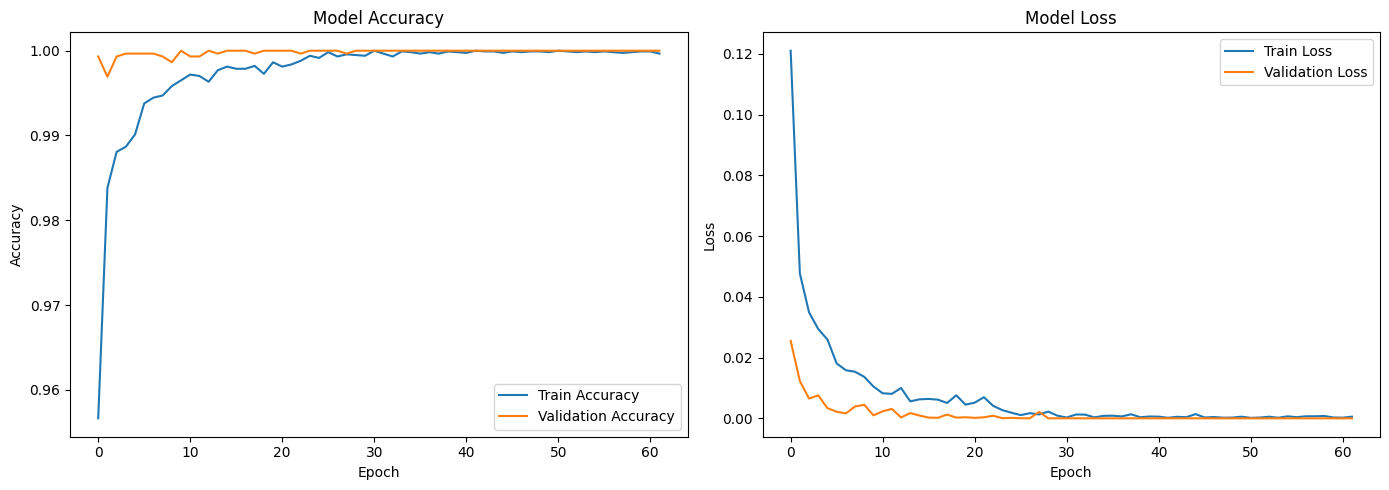

In [51]:
# ==========================================================
# Training History
# ==========================================================

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

plt.show()

In [52]:
# ==========================================================
# Model Evaluation
# ==========================================================

# Predict probabilities
y_prob = model.predict(X_test_processed)

# Convert probabilities to labels
y_pred = (y_prob > 0.5).astype(int)

# Flatten arrays
y_pred = y_pred.flatten()
y_prob = y_prob.flatten()

print("="*60)
print("Accuracy :", round(accuracy_score(y_test, y_pred),4))
print("Precision:", round(precision_score(y_test, y_pred),4))
print("Recall   :", round(recall_score(y_test, y_pred),4))
print("F1 Score :", round(f1_score(y_test, y_pred),4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob),4))
print("="*60)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Accuracy : 0.9895
Precision: 0.9341
Recall   : 0.9398
F1 Score : 0.9369
ROC AUC  : 0.9973


In [53]:
# ==========================================================
# Classification Report
# ==========================================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1834
           1       0.93      0.94      0.94       166

    accuracy                           0.99      2000
   macro avg       0.96      0.97      0.97      2000
weighted avg       0.99      0.99      0.99      2000



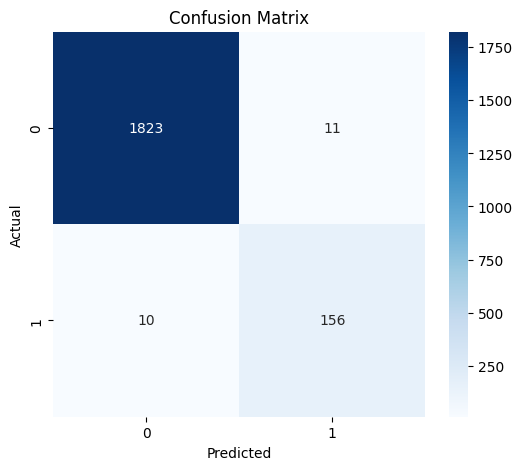

In [54]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

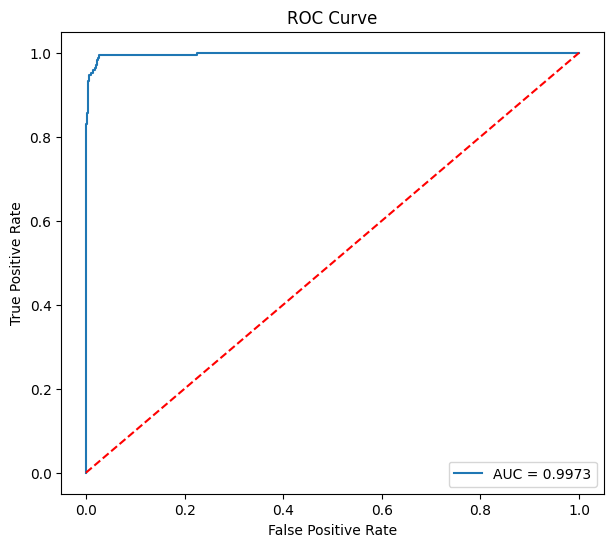

In [55]:
# ==========================================================
# ROC Curve
# ==========================================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test,y_prob):.4f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [56]:
# ==========================================================
# Save TensorFlow Model
# ==========================================================

os.makedirs("model", exist_ok=True)

model.save("model/best_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [57]:
# ==========================================================
# Save Preprocessor
# ==========================================================

joblib.dump(preprocessor, "model/preprocessor.pkl")

print("Preprocessor Saved Successfully!")

Preprocessor Saved Successfully!


In [60]:
import os

folders = [
    "model",
    "prediction",
    "schema",
    "reports",
    "samples"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("All folders created successfully!")

All folders created successfully!


In [61]:
feature_columns = list(X.columns)

with open("schema/feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=4)

print("Feature Columns Saved!")

Feature Columns Saved!


In [62]:
# ==========================================================
# Save Input Schema
# ==========================================================

input_schema = {}

for col in X.columns:
    input_schema[col] = str(df[col].dtype)

with open("schema/input_schema.json", "w") as f:
    json.dump(input_schema, f, indent=4)

print("Input Schema Saved Successfully!")

Input Schema Saved Successfully!


In [63]:
# ==========================================================
# Save Output Schema
# ==========================================================

output_schema = {
    "prediction": "Fraud / Not Fraud",
    "fraud_probability": "float",
    "risk_level": "Low / Medium / High",
    "confidence": "float",
    "reasons": ["string"],
    "model_version": "v1.0"
}

with open("schema/output_schema.json", "w") as f:
    json.dump(output_schema, f, indent=4)

print("Output Schema Saved Successfully!")

Output Schema Saved Successfully!


In [64]:
# ==========================================================
# Save Sample Input
# ==========================================================

sample_input = X.iloc[0].to_dict()

with open("samples/sample_input.json", "w") as f:
    json.dump(sample_input, f, indent=4, default=str)

print("Sample Input Saved Successfully!")

Sample Input Saved Successfully!


In [65]:
# ==========================================================
# Save Sample Output
# ==========================================================

sample_output = {
    "prediction": "Not Fraud",
    "fraud_probability": 0.18,
    "risk_level": "Low",
    "confidence": 0.82,
    "reasons": [
        "Normal claim amount",
        "No suspicious claim history"
    ],
    "model_version": "v1.0"
}

with open("samples/sample_output.json", "w") as f:
    json.dump(sample_output, f, indent=4)

print("Sample Output Saved Successfully!")

Sample Output Saved Successfully!


In [66]:
# ==========================================================
# Save Model Metrics
# ==========================================================

metrics_text = f"""
Healthcare Fraud Detection Model

Accuracy : {accuracy_score(y_test, y_pred):.4f}

Precision : {precision_score(y_test, y_pred):.4f}

Recall : {recall_score(y_test, y_pred):.4f}

F1 Score : {f1_score(y_test, y_pred):.4f}

ROC AUC : {roc_auc_score(y_test, y_prob):.4f}
"""

with open("reports/model_metrics.md", "w") as f:
    f.write(metrics_text)

print("Model Metrics Saved Successfully!")

Model Metrics Saved Successfully!


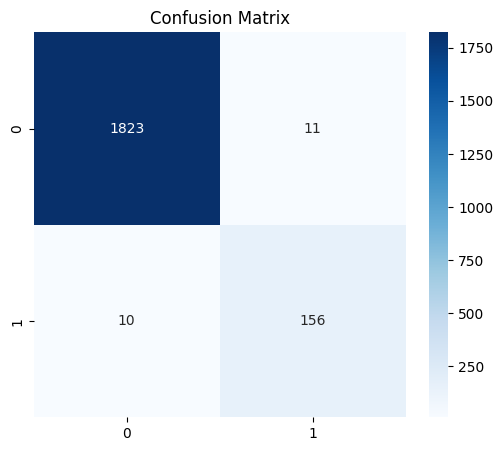

Confusion Matrix Saved Successfully!


In [67]:
# ==========================================================
# Save Confusion Matrix
# ==========================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.savefig("reports/confusion_matrix.png")

plt.show()

print("Confusion Matrix Saved Successfully!")